# Zero-D model

In [223]:
#  define a function for calculating equivalent temperature for earth assuming 0D-model

def equilibrium_temperature(alpha,Q,tau):
    T_eq = ((1-alpha)*Q/(tau*sigma))**(1/4)
    return T_eq


In [224]:
# calculating transmissivity for earth

OLRobserved = 238.5  # in W/m2
sigma = 5.67e-8  # S-B constant
Tsobserved = 288.  # global average surface temperature
tau_observed = OLRobserved / sigma / Tsobserved**4  # solve for tuned value of transmissivity
print(tau_observed)

0.6114139923687016


In [225]:
# incoming Solar Radiation 
Q = 341.3
alpha = 0.298 # for earth

In [226]:
Teq = equilibrium_temperature(alpha,Q,1)
print ("Equivalent Surface temperature" , Teq)

Teq_observed = equilibrium_temperature(alpha,Q,tau_observed)
print ("Observed Surface temperature" , Teq_observed)

Equivalent Surface temperature 254.96031403013674
Observed Surface temperature 288.3292763761165


# Time dependendent Energy Balance model 

In [227]:
dt = 60. * 60. * 24. * 365.   # one year expressed in seconds

In [228]:
# calcluating effective heat capacity
# refer to equation 6,
def heatCapacity(c_w=4E3, rho_w=1E3, H=100):
    # c_w = 4E3  #  Specific heat of water in J/kg/K
    # rho_w = 1E3  #  Density of water in kg/m3
    # H = 100.   #  Depth of water in m
    C = c_w * rho_w * H   #  Heat capacity of the model
    return C

C = heatCapacity()
print('The effective heat capacity is {:.1e} J/m2/K'.format(C))

The effective heat capacity is 4.0e+08 J/m2/K


In [229]:
# defining functions to calculate Absorbed Solar radiation and Outgoing Longwave Radiation 
# refer to equation 1(a,b)
def ASR(Q, alpha):
    return (1-alpha)*Q

def OLR(T, tau):
    return tau * sigma * T**4

In [230]:
# Refer to equation 10 under numerical solution for "Energy balance Model"

T1 = 288 # assuming the current state of temperature
T2 = T1 + dt / C * ( ASR(Q, alpha) - OLR(T1, tau=0.57) )
print(T2)

289.3597806854462


In [231]:
# let us define a function for calculating future temperature as done in the precious cell

def future_temperature (T1, hC, alphedo):
    
    T2 = T1 + dt / hC * ( ASR(Q, alpha=alphedo) - OLR(T1, tau=0.57) )

    return T2


In [232]:
future_temperature (300, C, alpha)

298.250437908

# Future Temperature plot using the simple 0D-model

In [233]:
import numpy as np

def future_climate (T, C, alpha):
    
    numsteps = 20  #future temperature for next 20 years
    Tsteps = np.zeros(numsteps+1) # dummy array to store the temperature values
    
    Tsteps[0] = T 
    
    for n in range(numsteps):
        Tsteps[n+1] = future_temperature( Tsteps[n], C, alpha) 
        
    return Tsteps


In [234]:
T_future = future_climate (288, C, alpha)

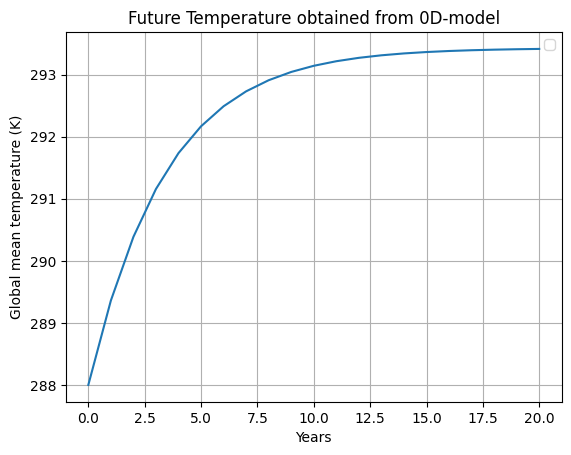

In [235]:
import matplotlib.pyplot as plt
plt.plot(T_future)
plt.xlabel('Years', )
plt.ylabel('Global mean temperature (K)')
plt.title ("Future Temperature obtained from 0D-model")
plt.grid()
plt.legend ()

### Future Temperature on different Initial temperatures

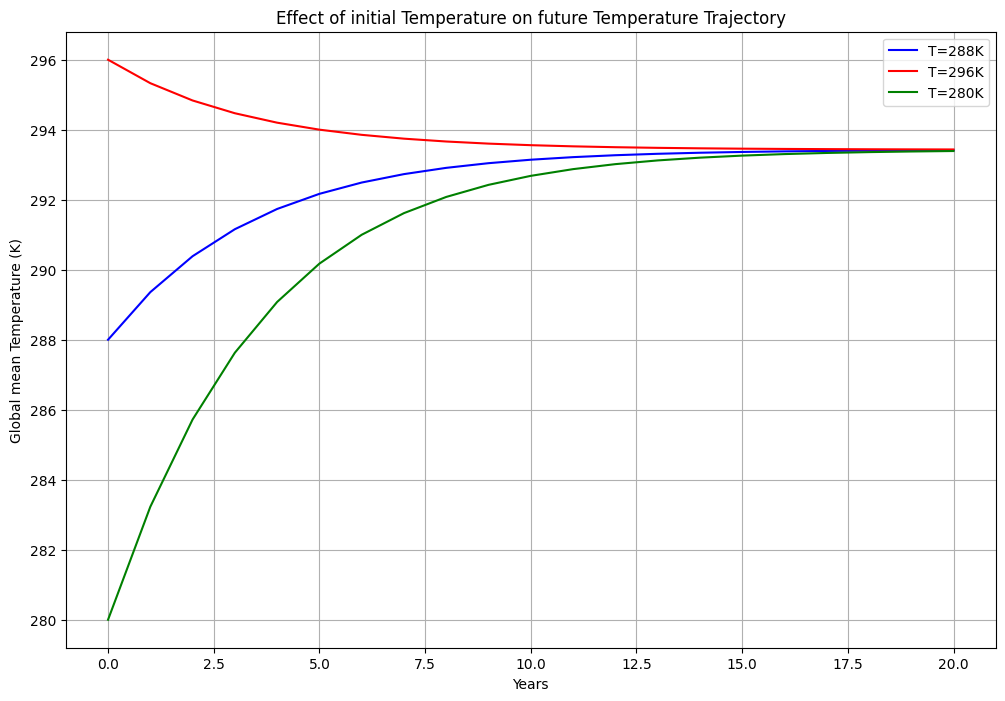

In [236]:
T_future_288 = future_climate(288, C, alpha)
T_future_296 = future_climate(296, C, alpha)
T_future_280 = future_climate(280, C, alpha)

plt.figure(figsize=(12,8))

plt.plot(T_future_288, color='b', label="T=288K")
plt.plot(T_future_296, color='r', label="T=296K")
plt.plot(T_future_280, color='g', label="T=280K")
plt.xlabel("Years")
plt.ylabel("Global mean Temperature (K)")
plt.title("Effect of initial Temperature on future Temperature Trajectory")
plt.grid()
plt.legend()
# plt.savefig("Temp-vary-futureTemp.png")

### Future Temperature trajectory on different surface alphedo

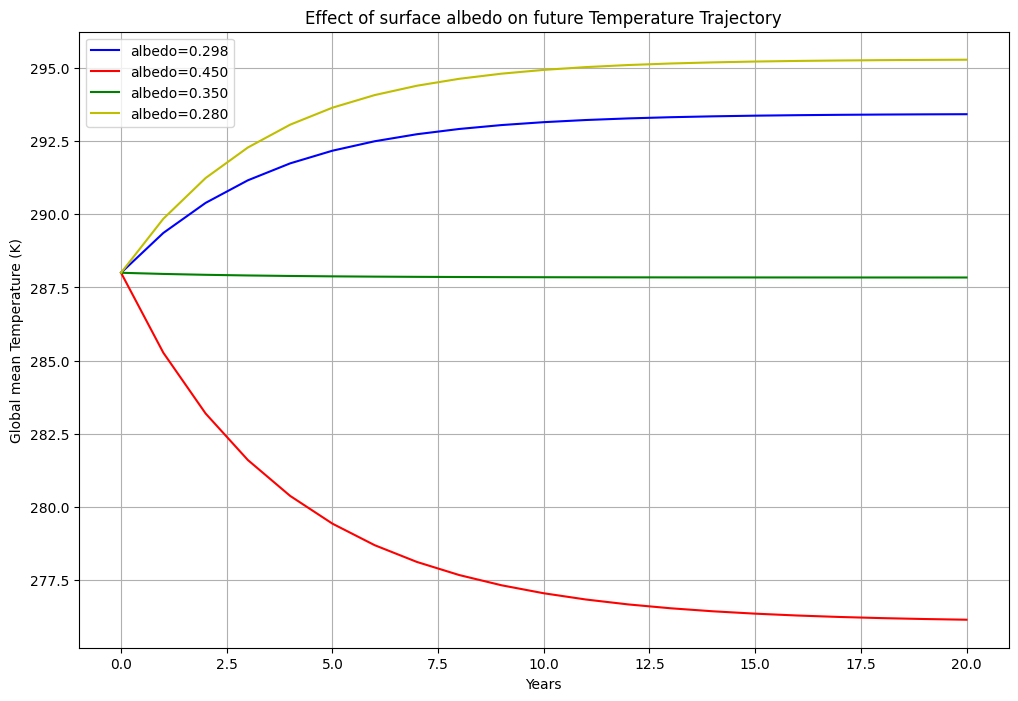

In [237]:
T_future = future_climate(288, C, alpha)
alpha = 0.450
T_future_45 = future_climate(288, C, alpha)
alpha = 0.350
T_future_35 = future_climate(288, C, alpha)
alpha = 0.280
T_future_28 = future_climate(288, C, alpha)

plt.figure(figsize=(12,8))

plt.plot(T_future, color='b', label="albedo=0.298")
plt.plot(T_future_45, color='r', label="albedo=0.450")
plt.plot(T_future_35, color='g', label="albedo=0.350")
plt.plot(T_future_28, color='y', label="albedo=0.280")
plt.xlabel("Years")
plt.ylabel("Global mean Temperature (K)")
plt.title("Effect of surface albedo on future Temperature Trajectory")
plt.grid()
plt.legend()
plt.savefig("Surface-Alphedo-vary-futureTemp.png")

### Effect of different heat Capacity on future Temperature trajectory

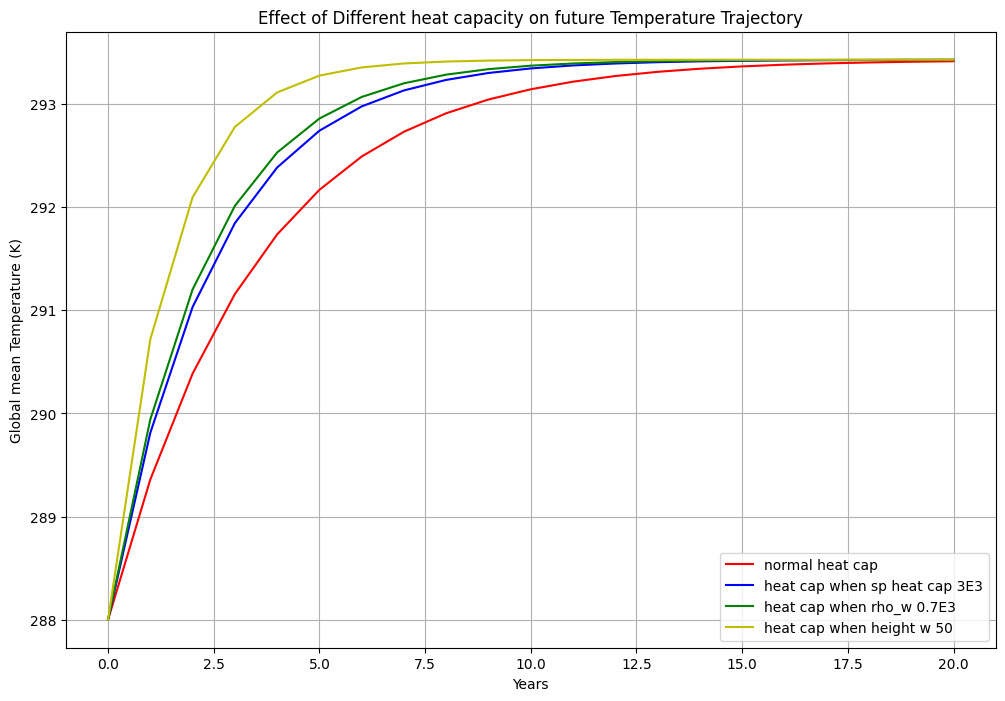

In [238]:
alpha = 0.298 #original alphedoe
    # c_w = 4E3  #  Specific heat of water in J/kg/K
    # rho_w = 1E3  #  Density of water in kg/m3
    # H = 100.   #  Depth of water in m
T_future = future_climate(288, C, alpha)
hc1 = heatCapacity(c_w=3E3)
T_future_SC = future_climate(288, hc1, alpha)
hc2 = heatCapacity(rho_w=0.7E3)
T_future_Rho = future_climate(288, hc2, alpha)
hc3 = heatCapacity(H=50)
T_future_h = future_climate(288, hc3, alpha)

plt.figure(figsize=(12,8))

plt.plot(T_future, color='r', label = 'normal heat cap')
plt.plot(T_future_SC, color='b', label='heat cap when sp heat cap 3E3')
plt.plot(T_future_Rho, color='g', label='heat cap when rho_w 0.7E3')
plt.plot(T_future_h, color='y', label='heat cap when height w 50')
plt.xlabel("Years")
plt.ylabel("Global mean Temperature (K)")
plt.title("Effect of Different heat capacity on future Temperature Trajectory")
plt.grid()
plt.legend()
# plt.savefig("Varying-Heat-Cap-vary-futureTemp.png")